# KNN Classification on the Iris Dataset

This notebook walks through how to use the K-Nearest Neighbors (KNN) algorithm to classify flowers from the Iris dataset. We will load the data, prepare it, test different K values, and evaluate how well KNN performs.

The Iris dataset is one of the most well-known datasets in machine learning. It has 150 flower samples split across 3 species, and each flower has 4 measurements. Our goal is to build a model that can correctly predict the species based on those measurements.

## Step 1: Import Libraries

Before we can do anything, we need to bring in the tools we will use. Each library has a specific job:
- **numpy** and **pandas** help us work with data
- **matplotlib** and **seaborn** let us make charts
- **sklearn** gives us the KNN algorithm and evaluation tools

In [1]:
# Import the libraries we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools from sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

## Step 2: Load the Iris Dataset

The Iris dataset comes built into sklearn, so we do not need to download a file. It has 150 flowers with 4 features each:
- Sepal length
- Sepal width
- Petal length
- Petal width

The target variable is the species of flower: Setosa (0), Versicolor (1), or Virginica (2).

In [2]:
# Load the Iris dataset from sklearn
iris = load_iris()

# Put the data into a pandas DataFrame so it is easier to read
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the species column (this is what we want to predict)
df['species'] = iris.target

# Show the first 10 rows
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


## Step 3: Explore the Data

Before building any model, we should look at the data. We want to know how big it is, what the numbers look like, and whether there are any problems like missing values.

In [3]:
# Check the size of our dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 150
Number of columns: 5


In [4]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [5]:
# Look at basic statistics for each feature
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [6]:
# See how many flowers are in each species
print("Number of flowers per species:")
print(df['species'].value_counts())
print()
print("Species labels:")
for i in range(len(iris.target_names)):
    print(i, "=", iris.target_names[i])

Number of flowers per species:
species
0    50
1    50
2    50
Name: count, dtype: int64

Species labels:
0 = setosa
1 = versicolor
2 = virginica


The data looks good. There are no missing values and each species has exactly 50 samples. This is a balanced dataset, which means no class has more samples than the others. That makes our job easier because accuracy alone is a fair way to measure performance.

## Step 4: Prepare the Data

Now we need to get the data ready for KNN. There are three steps:
1. Separate the features from the target
2. Split the data into training and testing sets
3. Scale the features

We separate features and target because the model needs to know what it is learning from (features) and what it is trying to predict (target).

In [7]:
# Separate features (X) and target (y)
# X contains the 4 measurements, y contains the species label
X = df.drop('species', axis=1)
y = df['species']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


We split the data into two groups: a training set and a testing set. The training set is used to teach the model, and the testing set is used to check how well the model does on data it has never seen before. We use 80% for training and 20% for testing.

In [ ]:
# Split into training (80%) and testing (20%) sets
# random_state=42 makes sure we get the same split every time we run this
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% of data for testing
    random_state=42 # For reproducibility
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 120
Testing set size: 30


### Why We Scale the Features

KNN works by measuring the distance between data points. If one feature has much bigger numbers than another, it will have more influence on the distance calculation. For example, if sepal length ranges from 4 to 8 but petal width ranges from 0.1 to 2.5, sepal length would dominate just because its numbers are bigger.

Scaling puts all features on the same range so that each one contributes fairly to the distance. StandardScaler makes each feature have a mean of 0 and a standard deviation of 1.

In [9]:
# Scale the features using StandardScaler
scaler = StandardScaler()

# fit_transform learns the scaling from training data and applies it
X_train_scaled = scaler.fit_transform(X_train)

# transform applies the same scaling to test data (we do NOT fit on test data)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")
print()
print("Before scaling (first training sample):")
print(X_train.iloc[0].values)
print()
print("After scaling (same sample):")
print(X_train_scaled[0])

Scaling done.

Before scaling (first training sample):
[4.6 3.6 1.  0.2]

After scaling (same sample):
[-1.47393679  1.20365799 -1.56253475 -1.31260282]


## Step 5: Test KNN with Different K Values

The K value in KNN decides how many neighbors the algorithm checks when making a prediction. For example:
- K=1 means the model only looks at the single closest data point
- K=5 means the model looks at the 5 closest points and takes a majority vote
- K=51 means it checks 51 neighbors

We want to find the K value that gives us the best accuracy. We will test: 1, 3, 5, 7, 9, 11, 15, 20, 31, and 51.

In [10]:
# Test different K values and record the accuracy for each
k_values = [1, 3, 5, 7, 9, 11, 15, 20, 31, 51]
accuracies = []

for k in k_values:
    # Create a KNN model with this K value
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train the model on our training data
    knn.fit(X_train_scaled, y_train)

    # Make predictions on the test data
    predictions = knn.predict(X_test_scaled)

    # Calculate the accuracy and save it
    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)

    # Print the result for this K
    print("K = {:2d}  |  Accuracy = {:.4f}".format(k, accuracy))

K =  1  |  Accuracy = 1.0000
K =  3  |  Accuracy = 1.0000
K =  5  |  Accuracy = 1.0000
K =  7  |  Accuracy = 1.0000
K =  9  |  Accuracy = 1.0000
K = 11  |  Accuracy = 1.0000
K = 15  |  Accuracy = 1.0000
K = 20  |  Accuracy = 1.0000
K = 31  |  Accuracy = 0.9667
K = 51  |  Accuracy = 0.9333


Now we will plot the accuracy for each K value. This makes it easy to see the pattern and find the best K.

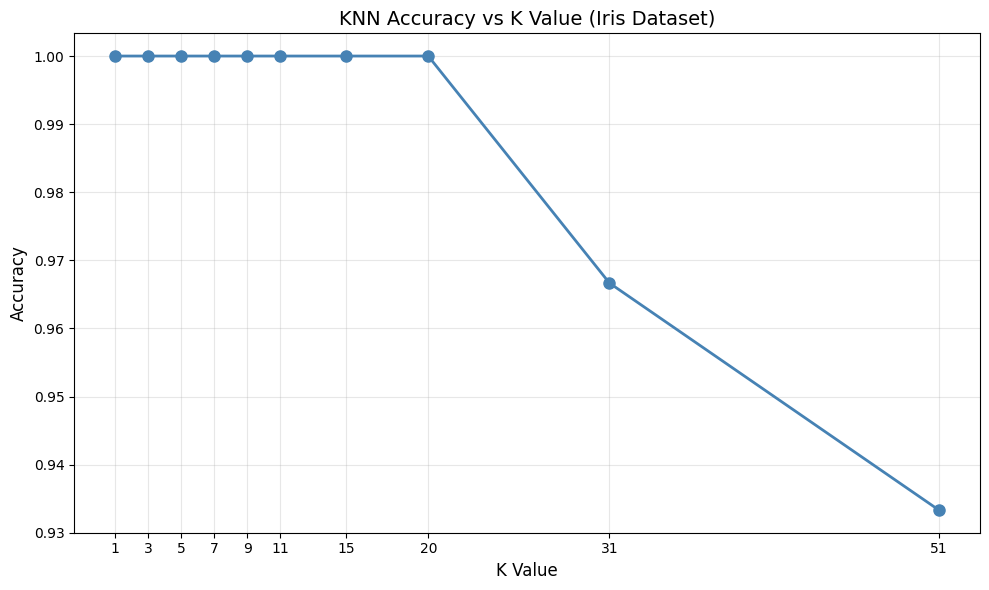

In [11]:
# Plot accuracy vs K value
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN Accuracy vs K Value (Iris Dataset)', fontsize=14)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Find the best K value
best_index = accuracies.index(max(accuracies))
best_k = k_values[best_index]
best_accuracy = max(accuracies)

print("Best K value:", best_k)
print("Best accuracy: {:.4f}".format(best_accuracy))

Best K value: 1
Best accuracy: 1.0000


## Step 6: The Bias-Variance Tradeoff

Looking at the plot above, there is an important pattern happening:

**When K is very small (like K=1):** The model pays too much attention to individual data points, including noisy or unusual ones. This is called **overfitting** (high variance). The model memorizes the training data instead of learning general patterns. It might score well on training data but poorly on new data.

**When K is very large (like K=51):** The model looks at too many neighbors, including ones that are far away and not really relevant. This is called **underfitting** (high bias). The model becomes too simple and misses the actual patterns in the data.

**The sweet spot is in the middle.** That is where the model balances between being too specific and too general. From our test, the best K value for the Iris dataset is shown above.

This balance between overfitting and underfitting is one of the most important ideas in machine learning. It is called the **bias-variance tradeoff**.

## Step 7: Final Model Evaluation

Now that we know the best K, we will train our final model and look at all the evaluation metrics.

In [13]:
# Train the final KNN model with the best K
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

# Make predictions with the final model
final_predictions = final_knn.predict(X_test_scaled)

# Calculate all the metrics
accuracy = accuracy_score(y_test, final_predictions)
precision = precision_score(y_test, final_predictions, average='weighted')
recall = recall_score(y_test, final_predictions, average='weighted')
f1 = f1_score(y_test, final_predictions, average='weighted')

print("=== Final KNN Model Results (K = {}) ===".format(best_k))
print()
print("Accuracy:  {:.4f}".format(accuracy))
print("Precision: {:.4f}".format(precision))
print("Recall:    {:.4f}".format(recall))
print("F1 Score:  {:.4f}".format(f1))

=== Final KNN Model Results (K = 1) ===

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


Here is what each metric means:
- **Accuracy** is the percentage of all predictions that were correct.
- **Precision** answers: of the flowers the model labeled as a certain species, how many actually were that species?
- **Recall** answers: of all the actual flowers of a species, how many did the model correctly find?
- **F1 Score** is a single number that balances precision and recall. It is useful when you want one metric that captures both.

### Confusion Matrix

The confusion matrix shows exactly where the model got things right and where it made mistakes. Each row is the actual species, and each column is what the model predicted. The numbers on the diagonal are correct predictions.

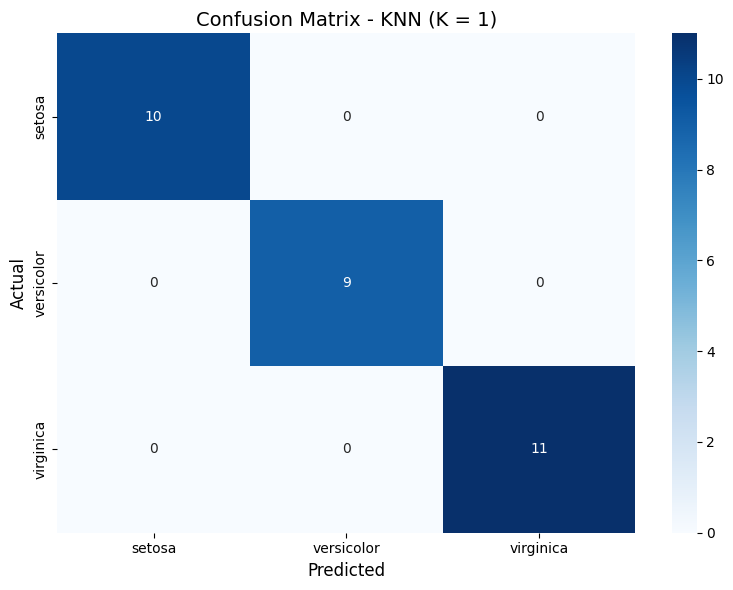

In [14]:
# Create the confusion matrix
cm = confusion_matrix(y_test, final_predictions)

# Plot it as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - KNN (K = {})'.format(best_k), fontsize=14)
plt.tight_layout()
plt.show()

### Classification Report

The classification report breaks down precision, recall, and F1 score for each species. This lets us see if the model is better at classifying some species than others.

In [15]:
# Print the full classification report
print("Classification Report:")
print()
print(classification_report(y_test, final_predictions, target_names=iris.target_names))

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Summary

In this notebook we used KNN to classify Iris flowers. Here is what we did:

1. Loaded the Iris dataset (150 flowers, 3 species, 4 features)
2. Checked the data and confirmed it was clean with no missing values
3. Split the data into 80% training and 20% testing
4. Scaled the features so distance calculations were fair
5. Tested K values from 1 to 51 to find the best one
6. Found that the optimal K value gave us the best balance between overfitting and underfitting
7. Evaluated the final model with accuracy, precision, recall, F1, and a confusion matrix

Next, we will run SVM on this same Iris dataset in a separate notebook so we can compare the two algorithms.